In [ ]:
from google.colab import files
import os

print("Lütfen kaggle.json dosyanızı yükleyin:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Veri seti Kaggle'dan indiriliyor...")
!kaggle datasets download -d asdasdasasdas/garbage-classification
!unzip -q garbage-classification.zip -d dataset/

print("✅ Veri seti başarıyla indirildi!")

Lütfen kaggle.json dosyanızı yükleyin:


Saving kaggle.json to kaggle.json
Veri seti Kaggle'dan indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
100% 82.0M/82.0M [00:06<00:00, 14.0MB/s]

✅ Veri seti başarıyla indirildi!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

data_dir = 'dataset/Garbage classification/Garbage classification'
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123,
    image_size=img_size, batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=img_size, batch_size=batch_size)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"✅ Sınıflar Tanımlandı: {class_names}")

# Geometriyi çok bozmadan güvenli artırma
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.1),
  layers.RandomContrast(0.1),
])

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
✅ Sınıflar Tanımlandı: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
# 1. Mobilenet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Temel ağırlıkları ilk aşama için donduruyoruz
base_model.trainable = False

# 2. Kendi Atık Sınıflandırıcımız
model = tf.keras.Sequential([
  data_augmentation,
  base_model,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(), # Stabilite için ekstra bir dengeleyici
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.3), # Ezberlemeyi önleyici kalkan
  layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("✅ MobileNetV2 Mimarisi Güvenle Kuruldu!")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ MobileNetV2 Mimarisi Güvenle Kuruldu!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

print("🚀 Aşama 1: Temel Eğitim Başlıyor...")
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)
print("✅ Temel Eğitim Tamamlandı!")

🚀 Aşama 1: Temel Eğitim Başlıyor...
Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - accuracy: 0.5297 - loss: 1.4281 - val_accuracy: 0.6020 - val_loss: 1.1104
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.6167 - loss: 1.0866 - val_accuracy: 0.6495 - val_loss: 0.9627
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.6795 - loss: 0.9141 - val_accuracy: 0.6871 - val_loss: 0.8621
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.6686 - loss: 0.9133 - val_accuracy: 0.6970 - val_loss: 0.7957
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.7092 - loss: 0.8317 - val_accuracy: 0.7327 - val_loss: 0.7646
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.7310 - loss: 0.7504 - val_accuracy: 0.7129 - val_loss: 0.8066
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.7181 - loss: 0.7568 - val_accuracy: 0.7030 - val_loss: 0.8448
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.7428 - l

In [ ]:
# Tüm katmanların kilidini açıyoruz
base_model.trainable = True

# Yıkıcı unutmayı engellemek için
# MobileNetV2 içindeki tüm BatchNormalization katmanlarına kilit vuruyoruz
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Öğrenme hızını tıkanıklıkta düşüren sistem
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)

# Çok düşük bir hız (1e-5) 100 kat yavaşlattık ile hassas derleme
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("🎯 Aşama 2: Güvenli İnce Ayar (Safe Fine-Tuning) Başlıyor...")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, lr_reducer]
)
print("✅ Kusursuz İnce Ayar Tamamlandı!")

🎯 Aşama 2: Güvenli İnce Ayar (Safe Fine-Tuning) Başlıyor...
Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 181ms/step - accuracy: 0.7324 - loss: 0.7591 - val_accuracy: 0.7129 - val_loss: 0.8001 - learning_rate: 1.0000e-05
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.7453 - loss: 0.7123 - val_accuracy: 0.7248 - val_loss: 0.7967 - learning_rate: 1.0000e-05
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.7458 - loss: 0.7051 - val_accuracy: 0.7624 - val_loss: 0.7017 - learning_rate: 1.0000e-05
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.7577 - loss: 0.6749 - val_accuracy: 0.7208 - val_loss: 0.7790 - learning_rate: 1.0000e-05
Epoch 5/15
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7503 - loss: 0.6699
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.7591 - loss: 0.6459 - val_accuracy: 0.7149 - val_loss: 0.7787 - learning_rate: 1.0000e-05
Epoch 

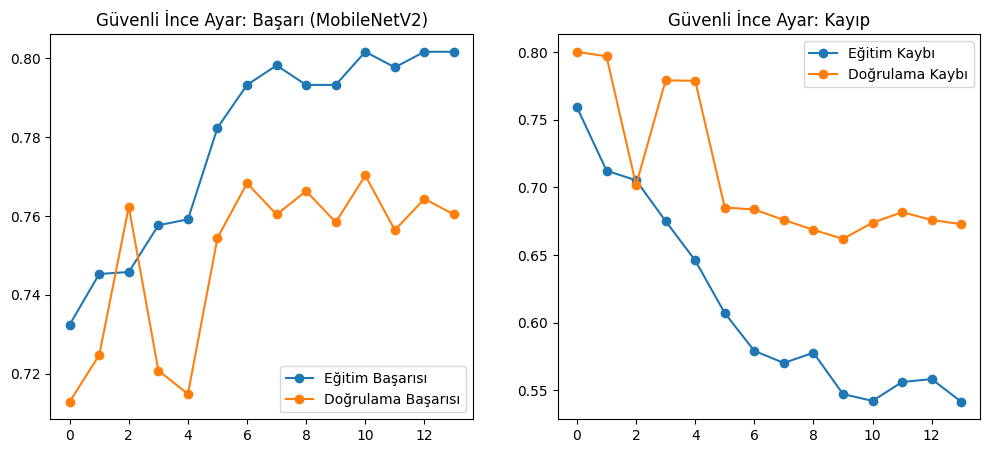

📊 Karmaşıklık Matrisi Hesaplanıyor...

--- Final Sınıflandırma Raporu ---
              precision    recall  f1-score   support

   cardboard     0.8902    0.8795    0.8848        83
       glass     0.7075    0.7282    0.7177       103
       metal     0.7534    0.7051    0.7285        78
       paper     0.8201    0.9194    0.8669       124
     plastic     0.6420    0.5909    0.6154        88
       trash     0.5833    0.4828    0.5283        29

    accuracy                         0.7584       505
   macro avg     0.7328    0.7176    0.7236       505
weighted avg     0.7537    0.7584    0.7548       505



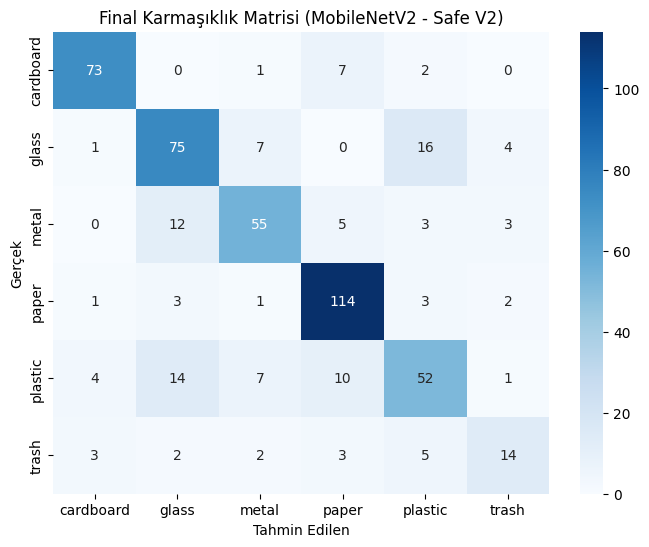

💾 Model 'Garbage_Classification_MobileNet_Safe.h5' olarak kaydedildi!


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Sadece İnce Ayar (Stage 2) sonuçlarını çizdiriyoruz
acc = history_stage2.history['accuracy']
val_acc = history_stage2.history['val_accuracy']
loss = history_stage2.history['loss']
val_loss = history_stage2.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarısı', marker='o')
plt.plot(epochs_range, val_acc, label='Doğrulama Başarısı', marker='o')
plt.legend(loc='lower right')
plt.title('Güvenli İnce Ayar: Başarı (MobileNetV2)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı', marker='o')
plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı', marker='o')
plt.legend(loc='upper right')
plt.title('Güvenli İnce Ayar: Kayıp')
plt.show()

# Matris ve Rapor
print("📊 Karmaşıklık Matrisi Hesaplanıyor...")
y_true, y_pred_probs = [], []
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    y_pred_probs.extend(model.predict(images, verbose=0))

y_true = np.array(y_true)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n--- Final Sınıflandırma Raporu ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title('Final Karmaşıklık Matrisi (MobileNetV2 - Safe V2)')
plt.show()

# Final Modeli Kaydet
model.save('Garbage_Classification_MobileNet_Safe.h5')
print("💾 Model 'Garbage_Classification_MobileNet_Safe.h5' olarak kaydedildi!")

In [ ]:
import tensorflow as tf
# Modeli yüklüyoruz ve sınıfları tanıtıyoruz
model = tf.keras.models.load_model('Garbage_Classification_Model.h5')
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
print("Model başarıyla yüklendi, şova hazır!")

Model başarıyla yüklendi, şova hazır!


In [ ]:
!pip install -q gradio
import gradio as gr
import tensorflow as tf
import numpy as np

def predict_image(img):
    img = tf.image.resize(img, (224, 224))
    img = tf.expand_dims(img, 0)
    prediction = model.predict(img)[0]
    confidences = {class_names[i]: float(prediction[i]) for i in range(len(class_names))}
    return confidences

demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy", label="Test Etmek İçin Atık Fotoğrafı Yükle"),
    outputs=gr.Label(num_top_classes=3, label="Yapay Zekanın Analizi"),
    title="♻️ Geri Dönüşüm Otomasyonu - Güvenli V2.0",
    description="Sivas Cumhuriyet Üniversitesi - Derin Öğrenme Projesi (MobileNetV2 - Safe Fine-Tuned)",
    theme="default"
)

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6cf581971736794f6e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
